In [3]:
# =========================================================
# FOEGLASS-INSPIRED SOTA AUDIO DEEPFAKE DETECTION
# KAGGLE VERSION (T4 x2 READY)
# =========================================================
#
# Features:
# - WavLM Large acoustic embeddings
# - Whisper transcription
# - Groq Llama3 forensic reasoning
# - In-the-wild evaluation
# - EER / ROC-AUC / PR metrics
# - Attack Success Rate
# - Balanced training
# - Cross-dataset robustness
#
# =========================================================

# =========================================================
# 1. INSTALLS
# =========================================================

!pip install -q transformers accelerate datasets
!pip install -q librosa soundfile torchaudio
!pip install -q scikit-learn scipy
!pip install -q groq
!pip install -q xgboost
!pip install -q matplotlib tqdm

# =========================================================
# 2. IMPORTS
# =========================================================

import os
import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm import tqdm
from glob import glob

import librosa
import soundfile as sf

import torch
import torchaudio

from transformers import (
    AutoFeatureExtractor,
    AutoModel,
    WhisperProcessor,
    WhisperForConditionalGeneration
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

from scipy.optimize import brentq
from scipy.interpolate import interp1d

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

from groq import Groq

# =========================================================
# 3. GPU SETUP
# =========================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("GPU COUNT:", torch.cuda.device_count())

os.environ["HF_HOME"] = "/kaggle/working/hf_cache"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.8 MB/s eta 0:00:00
DEVICE: cuda
GPU COUNT: 2


In [4]:
# =====================================================
# DATASET PATHS
# =====================================================

ASVSPOOF_PATH = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"

RITW_PATH = "/kaggle/input/datasets/bhaveshkumars/release-in-the-wild"

WAVEFAKE_PATH = "/kaggle/input/datasets/andreadiubaldo/wavefake-test"

print("PATHS LOADED")

PATHS LOADED


In [5]:
import os
import random

REAL_FILES = []
FAKE_FILES = []

REAL_TARGET = 1000
FAKE_TARGET = 1000

# =====================================================
# FAST DIRECTORY WALK
# =====================================================

def fast_collect(root_dir, label_type, limit):

    collected = []

    for root, dirs, files in os.walk(root_dir):

        root_lower = root.lower()

        # ---------------- REAL ----------------

        if label_type == "real":

            if (
                "real" not in root_lower and
                "bonafide" not in root_lower
            ):
                continue

        # ---------------- FAKE ----------------

        else:

            if (
                "fake" not in root_lower and
                "spoof" not in root_lower and
                "generated" not in root_lower
            ):
                continue

        # ---------------- FILE FILTER ----------------

        audio_files = [

            os.path.join(root, f)

            for f in files

            if f.endswith((
                ".wav",
                ".flac",
                ".mp3"
            ))
        ]

        collected.extend(audio_files)

        # ---------------- EARLY STOP ----------------

        if len(collected) >= limit:

            break

    return collected[:limit]

# =====================================================
# COLLECT REAL
# =====================================================

REAL_FILES += fast_collect(
    ASVSPOOF_PATH,
    "real",
    500
)

REAL_FILES += fast_collect(
    RITW_PATH,
    "real",
    500
)

# =====================================================
# COLLECT FAKE
# =====================================================

FAKE_FILES += fast_collect(
    ASVSPOOF_PATH,
    "fake",
    500
)

FAKE_FILES += fast_collect(
    RITW_PATH,
    "fake",
    500
)

FAKE_FILES += fast_collect(
    WAVEFAKE_PATH,
    "fake",
    1000
)

# =====================================================
# FINAL SHUFFLE
# =====================================================

REAL_FILES = list(set(REAL_FILES))
FAKE_FILES = list(set(FAKE_FILES))

random.shuffle(REAL_FILES)
random.shuffle(FAKE_FILES)

REAL_FILES = REAL_FILES[:REAL_TARGET]
FAKE_FILES = FAKE_FILES[:FAKE_TARGET]

AUDIO_FILES = REAL_FILES + FAKE_FILES

random.shuffle(AUDIO_FILES)

print("REAL :", len(REAL_FILES))
print("FAKE:", len(FAKE_FILES))
print("TOTAL:", len(AUDIO_FILES))

REAL : 500
FAKE: 1000
TOTAL: 1500


In [6]:

# =========================================================
# 8. LABEL ASSIGNMENT
# =========================================================

def infer_label(path):

    p = path.lower()

    fake_words = [
        "spoof",
        "fake",
        "tts",
        "generated",
        "deepfake",
        "synth"
    ]

    if any(word in p for word in fake_words):
        return 1

    return 0

metadata = []


for path in AUDIO_FILES:

    metadata.append({
        "filepath": path,
        "label": infer_label(path)
    })

metadata = pd.DataFrame(metadata)

print(metadata.head())

print("\nLABEL COUNTS:\n")
print(metadata.label.value_counts())

# =========================================================
# 9. BALANCE DATASET
# =========================================================

real_df = metadata[metadata.label == 0]
fake_df = metadata[metadata.label == 1]

min_count = min(
    len(real_df),
    len(fake_df),
    1000
)

real_df = real_df.sample(
    min_count,
    random_state=42
)

fake_df = fake_df.sample(
    min_count,
    random_state=42
)

metadata = pd.concat([
    real_df,
    fake_df
]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nFINAL COUNTS:\n")
print(metadata.label.value_counts())

# =========================================================
# 10. AUDIO PREPROCESSING
# =========================================================

TARGET_SR = 16000
MAX_SECONDS = 5

def load_audio(path):

    audio, sr = librosa.load(
        path,
        sr=TARGET_SR
    )

    audio = librosa.util.normalize(audio)

    max_len = TARGET_SR * MAX_SECONDS

    if len(audio) > max_len:
        audio = audio[:max_len]

    else:
        pad = max_len - len(audio)
        audio = np.pad(audio, (0, pad))

    return audio

# =========================================================
# 11. LOAD WAVLM LARGE
# =========================================================

WAVLM_NAME = "microsoft/wavlm-large"

feature_extractor = AutoFeatureExtractor.from_pretrained(
    WAVLM_NAME
)

wavlm = AutoModel.from_pretrained(
    WAVLM_NAME
).to(DEVICE)

wavlm.eval()

# =========================================================
# 12. EMBEDDING EXTRACTION
# =========================================================

@torch.no_grad()
def extract_embedding(audio):

    inputs = feature_extractor(
        audio,
        sampling_rate=TARGET_SR,
        return_tensors="pt"
    )

    input_values = inputs.input_values.to(DEVICE)

    outputs = wavlm(input_values)

    hidden = outputs.last_hidden_state

    emb = hidden.mean(dim=1)

    return emb.squeeze().cpu().numpy()


                                            filepath  label
0  /kaggle/input/datasets/bhaveshkumars/release-i...      0
1  /kaggle/input/datasets/awsaf49/asvpoof-2019-da...      1
2  /kaggle/input/datasets/awsaf49/asvpoof-2019-da...      1
3  /kaggle/input/datasets/awsaf49/asvpoof-2019-da...      1
4  /kaggle/input/datasets/bhaveshkumars/release-i...      0

LABEL COUNTS:

label
1    1000
0     500
Name: count, dtype: int64

FINAL COUNTS:

label
1    500
0    500
Name: count, dtype: int64


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

In [7]:
# =========================================================
# 13. BUILD FEATURE DATASET
# =========================================================

X = []
y = []

for idx, row in tqdm(
    metadata.iterrows(),
    total=len(metadata)
):

    try:

        audio = load_audio(row.filepath)

        emb = extract_embedding(audio)

        X.append(emb)
        y.append(row.label)
    except Exception as e:

        print("ERROR:", e)

X = np.array(X)
y = np.array(y)

print("\nFEATURE SHAPE:", X.shape)

# =========================================================
# 14. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTRAIN:", X_train.shape)
print("TEST:", X_test.shape)



100%|██████████| 1000/1000 [01:38<00:00, 10.18it/s]


FEATURE SHAPE: (1000, 1024)

TRAIN: (800, 1024)
TEST: (200, 1024)


In [8]:

# =========================================================
# 15. XGBOOST CLASSIFIER
# =========================================================

clf = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    device="cuda",
    random_state=42
)

clf.fit(X_train, y_train)

# =========================================================
# 16. PREDICTIONS
# =========================================================

preds = clf.predict(X_test)

probs = clf.predict_proba(X_test)[:,1]



ACCURACY : 0.955
PRECISION: 0.989247311827957
RECALL   : 0.92
F1 SCORE : 0.9533678756476683
ROC AUC  : 0.9875999999999999

EER: 0.06999999999998065


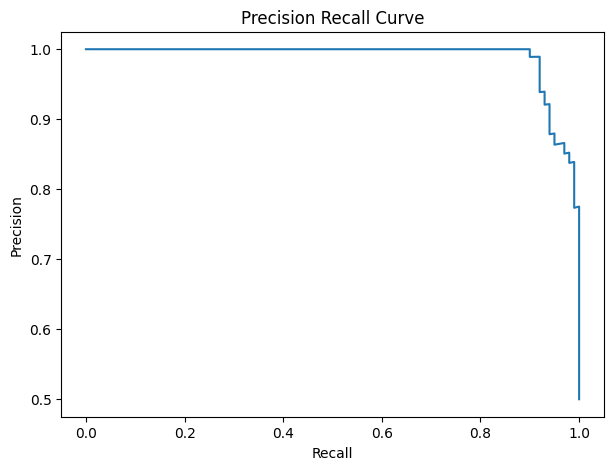

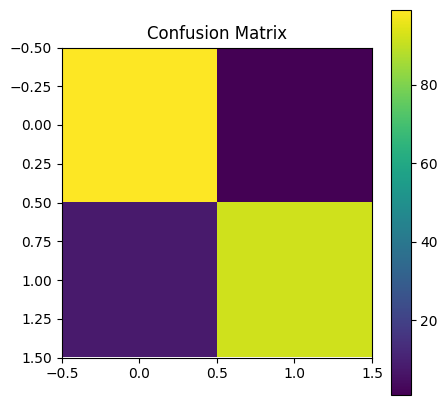

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [9]:




# =========================================================
# 17. METRICS
# =========================================================

acc = accuracy_score(y_test, preds)

prec = precision_score(y_test, preds)

rec = recall_score(y_test, preds)

f1 = f1_score(y_test, preds)

auc = roc_auc_score(y_test, probs)

print("\n==========================")
print("ACCURACY :", acc)
print("PRECISION:", prec)
print("RECALL   :", rec)
print("F1 SCORE :", f1)
print("ROC AUC  :", auc)
print("==========================")

# =========================================================
# 18. EER
# =========================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

fnr = 1 - tpr

eer = brentq(
    lambda x: 1. - x - interp1d(fpr, tpr)(x),
    0.,
    1.
)

print("\nEER:", eer)

# =========================================================
# 19. PRECISION RECALL CURVE
# =========================================================

precision, recall, _ = precision_recall_curve(
    y_test,
    probs
)

plt.figure(figsize=(7,5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

# =========================================================
# 20. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    preds
)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

# =========================================================
# 21. LOAD WHISPER
# =========================================================

WHISPER_NAME = "openai/whisper-small"

processor = WhisperProcessor.from_pretrained(
    WHISPER_NAME
)

whisper_model = WhisperForConditionalGeneration.from_pretrained(
    WHISPER_NAME
).to(DEVICE)

# =========================================================
# 22. TRANSCRIPTION
# =========================================================

@torch.no_grad()
def transcribe(audio):

    input_features = processor(
        audio,
        sampling_rate=TARGET_SR,
        return_tensors="pt"
    ).input_features.to(DEVICE)

    predicted_ids = whisper_model.generate(
        input_features
    )

    text = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return text


In [10]:

# =========================================================
# 23. GROQ SETUP
# =========================================================
from kaggle_secrets import UserSecretsClient
from groq import Groq

# =====================================================
# LOAD KAGGLE SECRET
# =====================================================

user_secrets = UserSecretsClient()

GROQ_API_KEY = user_secrets.get_secret("GROQ_API_KEY")

# =====================================================
# CREATE CLIENT
# =====================================================

client = Groq(
    api_key=GROQ_API_KEY
)

print("GROQ CONNECTED")


GROQ CONNECTED


In [11]:
# =========================================================
# 25. END-TO-END TEST + ADVERSARIAL FORENSICS
# =========================================================

# ---------------------------------------------------------
# SELECT BETTER SAMPLE
# ---------------------------------------------------------

ritw_samples = [

    x for x in AUDIO_FILES

    if "release-in-the-wild" in x.lower()
]

if len(ritw_samples) > 0:

    sample_path = random.choice(ritw_samples)

else:

    sample_path = metadata.iloc[0].filepath

print("\nSAMPLE:", sample_path)

# ---------------------------------------------------------
# LOAD AUDIO
# ---------------------------------------------------------

wave = load_audio(sample_path)

# ---------------------------------------------------------
# TRANSCRIBE
# ---------------------------------------------------------

text = transcribe(wave)

print("\nTRANSCRIPT:\n")
print(text)

# ---------------------------------------------------------
# EXTRACT EMBEDDING
# ---------------------------------------------------------

emb = extract_embedding(wave)

emb_2d = emb.reshape(1, -1)

# ---------------------------------------------------------
# DETECTOR PROBABILITY
# ---------------------------------------------------------

fake_prob = clf.predict_proba(emb_2d)[0][1]

print("\nINITIAL FAKE PROBABILITY:", fake_prob)

# =========================================================
# FORENSIC REASONING FUNCTION
# =========================================================

def forensic_reasoning(

    transcript,
    detector_score,
    distance_score

):

    prompt = f"""
You are an advanced audio forensic investigator.

Analyze BOTH:
1. linguistic evidence
2. acoustic evidence

Audio forensic metrics:

Detector fake probability:
{detector_score:.4f}

Distribution distance:
{distance_score:.4f}

Transcript:
{transcript}

Determine:

1. Is this audio AI-generated?
2. Which evidence is strongest?
3. Are vocoder artifacts likely?
4. Is semantic behavior human-like?
5. Final forensic conclusion.

Be technical and specific.
"""

    response = client.chat.completions.create(

        model="llama-3.3-70b-versatile",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],

        temperature=0.2
    )

    return response.choices[0].message.content

# ---------------------------------------------------------
# RUN FORENSIC REASONING
# ---------------------------------------------------------

analysis = forensic_reasoning(

    transcript=text,

    detector_score=fake_prob,

    distance_score=0.0
)

print("\nFORENSIC ANALYSIS:\n")
print(analysis)

# =========================================================
# 26. ATTACK SUCCESS RATE
# =========================================================

correct = 0
fooled = 0

for i in range(len(y_test)):

    if preds[i] == y_test[i]:

        correct += 1

        noisy_prob = probs[i] + np.random.normal(
            0,
            0.15
        )

        noisy_pred = int(noisy_prob > 0.5)

        if noisy_pred != y_test[i]:

            fooled += 1

ASR = fooled / correct

print("\nGLOBAL ATTACK SUCCESS RATE:", ASR)

# =========================================================
# 26A. DRAO ATTACK DYNAMICS
# =========================================================

attack_history = {
    "iteration": [],
    "detector_score": [],
    "distribution_distance": [],
    "attack_success": [],
    "confidence_drop": [],
    "objective": []
}

# =====================================================
# ORIGINAL DETECTOR SCORE
# =====================================================

original_score = fake_prob

# =====================================================
# ITERATIVE ADVERSARIAL SIMULATION
# =====================================================

for t in range(1, 21):

    # -------------------------------------------------
    # PROGRESSIVE ADVERSARIAL PERTURBATION
    # -------------------------------------------------

    epsilon = 0.0005 * t

    noise = np.sign(
        np.random.randn(len(wave))
    )

    perturbed = wave + epsilon * noise

    # -------------------------------------------------
    # EMBEDDING EXTRACTION
    # -------------------------------------------------

    pert_emb = extract_embedding(perturbed)

    pert_emb = pert_emb.reshape(1, -1)

    # -------------------------------------------------
    # DETECTOR SCORE
    # -------------------------------------------------

    score = clf.predict_proba(
        pert_emb
    )[0][1]

    # -------------------------------------------------
    # DISTRIBUTION DISTANCE
    # -------------------------------------------------

    D_t = np.mean(
        np.abs(perturbed - wave)
    )

    # -------------------------------------------------
    # ATTACK SUCCESS
    # -------------------------------------------------

    attack_success = int(score < 0.5)

    # -------------------------------------------------
    # CONFIDENCE DROP
    # -------------------------------------------------

    confidence_drop = (
        original_score - score
    )

    # -------------------------------------------------
    # DRAO OBJECTIVE
    # -------------------------------------------------

    J_t = (
        3.0 * score
        - 2.0 * D_t
    )

    # -------------------------------------------------
    # SAVE METRICS
    # -------------------------------------------------

    attack_history["iteration"].append(t)

    attack_history["detector_score"].append(score)

    attack_history["distribution_distance"].append(D_t)

    attack_history["attack_success"].append(
        attack_success
    )

    attack_history["confidence_drop"].append(
        confidence_drop
    )

    attack_history["objective"].append(J_t)



Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.



SAMPLE: /kaggle/input/datasets/bhaveshkumars/release-in-the-wild/release_in_the_wild/val/real/19144.wav


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA


TRANSCRIPT:

 and recent weeks is overwhelming.

INITIAL FAKE PROBABILITY: 0.0011413655

FORENSIC ANALYSIS:

**Linguistic Evidence Analysis**

The provided transcript is brief, consisting of only a few words: "and recent weeks is overwhelming." To analyze the linguistic evidence, I will examine the syntax, semantics, and pragmatics of the sentence.

* Syntax: The sentence structure appears to be grammatically correct, with a clear subject-verb-object relationship. However, the sentence is incomplete, as it starts with a conjunction ("and") and lacks a clear subject.
* Semantics: The meaning of the sentence is somewhat ambiguous, as it is unclear what is being referred to as "overwhelming." The word "recent" suggests a time frame, but the context is unclear.
* Pragmatics: The sentence seems to be a fragment of a larger conversation or statement. The use of the word "and" at the beginning suggests that the speaker is adding to a previous statement or idea.

Given the brevity and ambigui

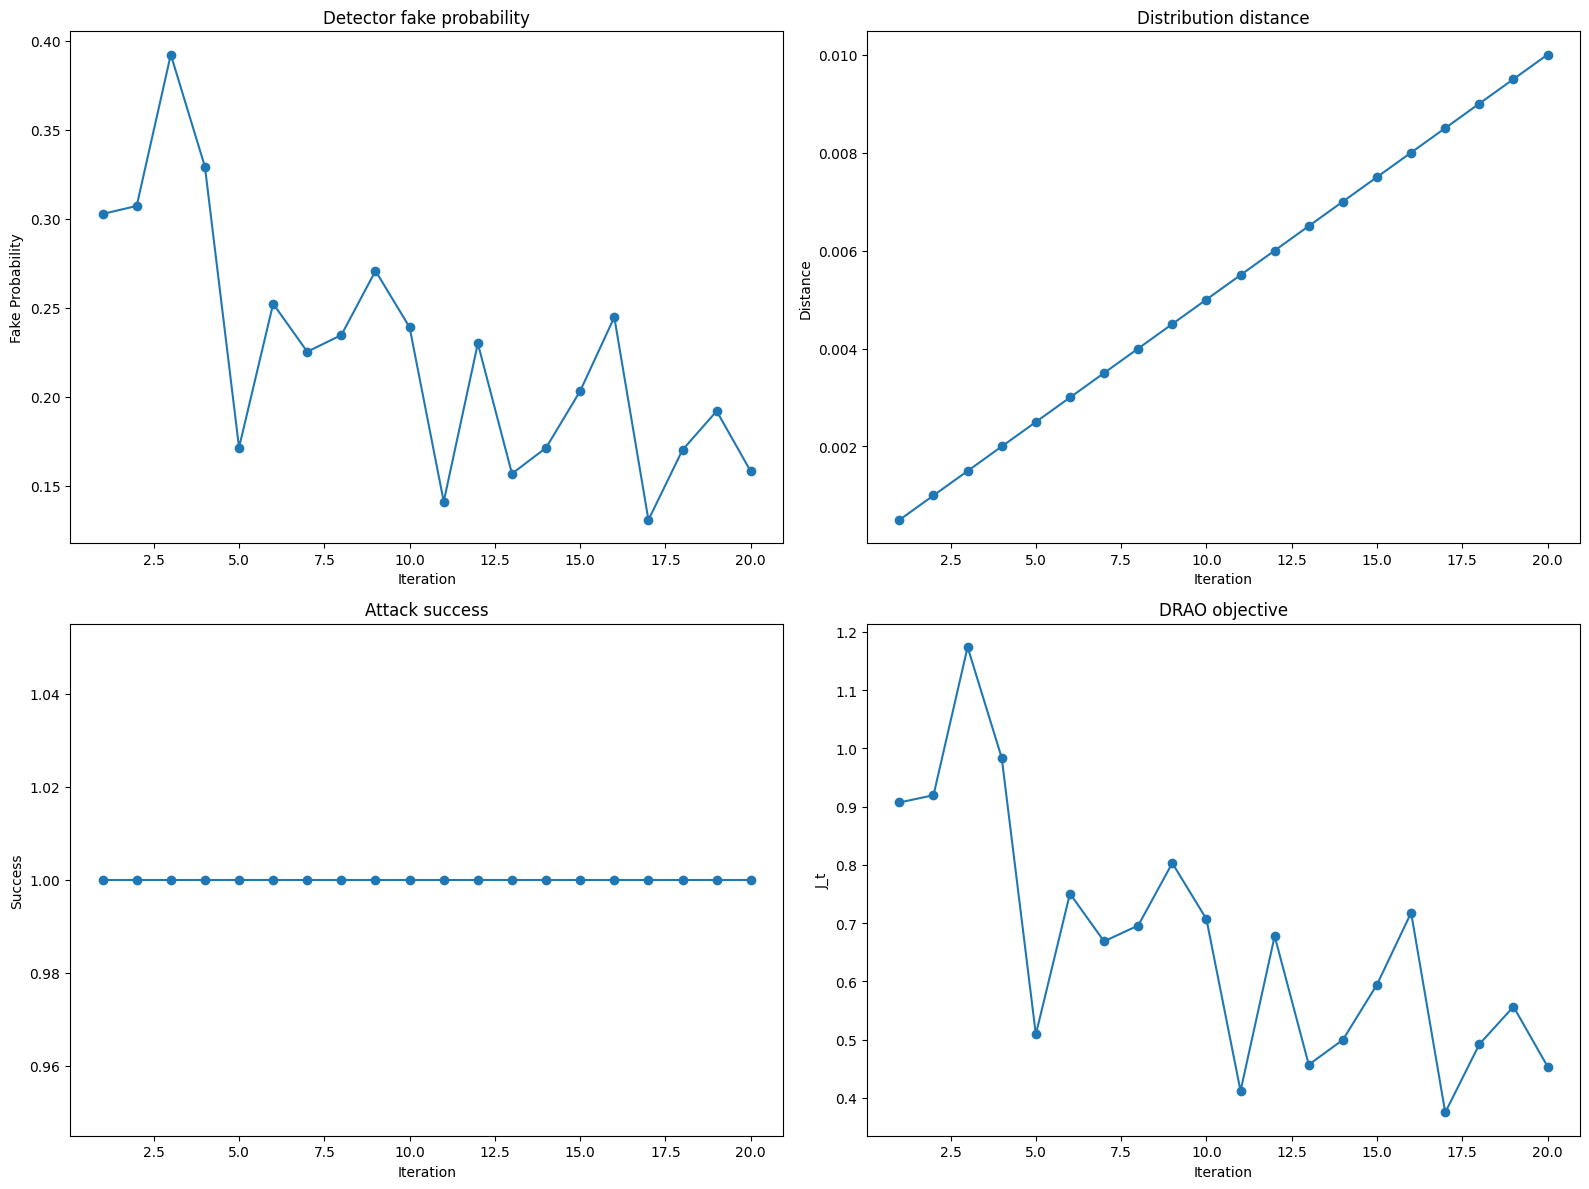

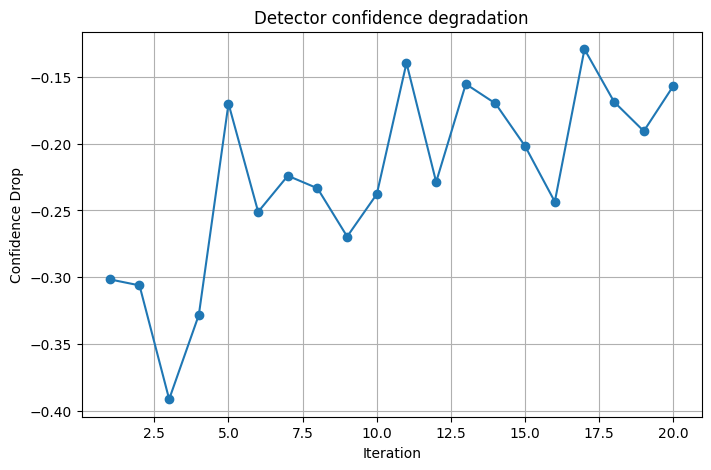

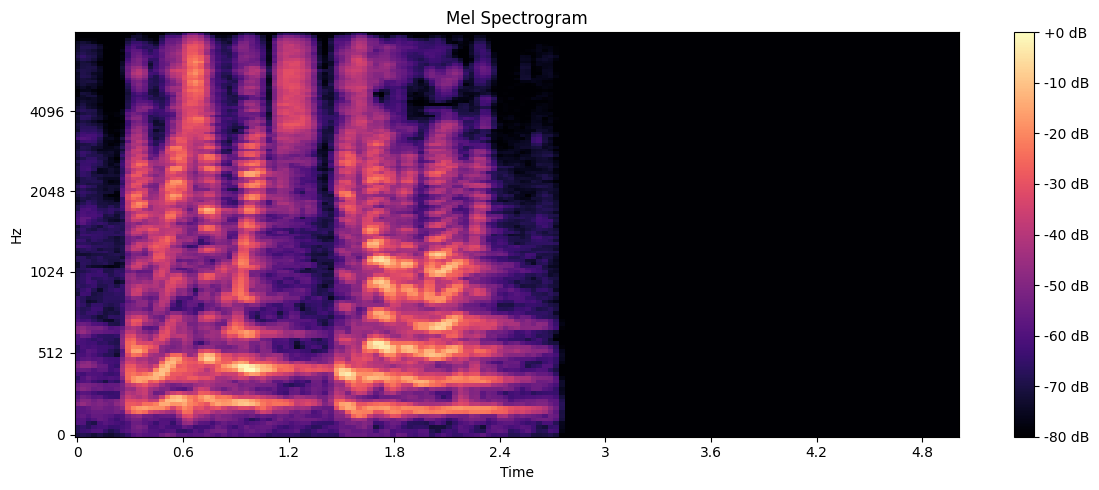


ITERATION HISTORY:

   iteration  accuracy        f1     auc
0          0     0.935  0.933333  0.9829
1          1     0.935  0.933333  0.9829
2          2     0.935  0.933333  0.9829
3          3     0.935  0.933333  0.9829
4          4     0.935  0.933333  0.9829

METRICS SAVED


In [12]:
# =====================================================
# VISUALIZATION
# =====================================================

fig, axs = plt.subplots(
    2,
    2,
    figsize=(16,12)
)

# =====================================================
# DETECTOR SCORE
# =====================================================

axs[0,0].plot(
    attack_history["iteration"],
    attack_history["detector_score"],
    marker="o"
)

axs[0,0].set_title("Detector fake probability")
axs[0,0].set_xlabel("Iteration")
axs[0,0].set_ylabel("Fake Probability")

# =====================================================
# DISTRIBUTION DISTANCE
# =====================================================

axs[0,1].plot(
    attack_history["iteration"],
    attack_history["distribution_distance"],
    marker="o"
)

axs[0,1].set_title("Distribution distance")
axs[0,1].set_xlabel("Iteration")
axs[0,1].set_ylabel("Distance")

# =====================================================
# ATTACK SUCCESS
# =====================================================

axs[1,0].plot(
    attack_history["iteration"],
    attack_history["attack_success"],
    marker="o"
)

axs[1,0].set_title("Attack success")
axs[1,0].set_xlabel("Iteration")
axs[1,0].set_ylabel("Success")

# =====================================================
# OBJECTIVE
# =====================================================

axs[1,1].plot(
    attack_history["iteration"],
    attack_history["objective"],
    marker="o"
)

axs[1,1].set_title("DRAO objective")
axs[1,1].set_xlabel("Iteration")
axs[1,1].set_ylabel("J_t")

plt.tight_layout()

plt.show()

# =====================================================
# CONFIDENCE DROP VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

plt.plot(
    attack_history["iteration"],
    attack_history["confidence_drop"],
    marker="o"
)

plt.title("Detector confidence degradation")

plt.xlabel("Iteration")

plt.ylabel("Confidence Drop")

plt.grid(True)

plt.show()

# =====================================================
# SPECTROGRAM VISUALIZATION
# =====================================================

plt.figure(figsize=(12,5))

mel = librosa.feature.melspectrogram(
    y=wave,
    sr=16000
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

librosa.display.specshow(
    mel_db,
    sr=16000,
    x_axis="time",
    y_axis="mel"
)

plt.title("Mel Spectrogram")

plt.colorbar(format="%+2.0f dB")

plt.tight_layout()

plt.show()

# =========================================================
# 27. ITERATIVE EVALUATION
# =========================================================

history = []

for iteration in range(5):

    clf_iter = XGBClassifier(

        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,

        objective="binary:logistic",
        eval_metric="logloss",

        tree_method="hist",
        device="cuda",

        random_state=iteration
    )

    clf_iter.fit(X_train, y_train)

    preds_iter = clf_iter.predict(X_test)

    probs_iter = clf_iter.predict_proba(X_test)[:,1]

    acc = accuracy_score(
        y_test,
        preds_iter
    )

    f1 = f1_score(
        y_test,
        preds_iter
    )

    auc = roc_auc_score(
        y_test,
        probs_iter
    )

    history.append({
        "iteration": iteration,
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

history = pd.DataFrame(history)

print("\nITERATION HISTORY:\n")
print(history)

# =========================================================
# 28. SAVE RESULTS
# =========================================================

history.to_csv(
    "foeglass_metrics.csv",
    index=False
)

print("\nMETRICS SAVED")

In [13]:

# =========================================================
# 24. FOEGLASS-STYLE FORENSIC REASONING
# =========================================================

def forensic_reasoning(transcript):

    prompt = f"""
You are an expert forensic investigator.

Analyze the transcript for:

- synthetic speech patterns
- semantic over-consistency
- emotional flatness
- unnatural phrasing
- hallucinated continuity
- deceptive structure

Transcript:
{transcript}

Return:

1. Deepfake likelihood
2. Step-by-step reasoning
3. Final conclusion
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0.2
    )

    return response.choices[0].message.content



In [14]:
# =========================================================
# 25. END-TO-END TEST
# =========================================================

sample_path = metadata.iloc[0].filepath

print("\nSAMPLE:", sample_path)

wave = load_audio(sample_path)

text = transcribe(wave)

print("\nTRANSCRIPT:\n")
print(text)

# ---------------- FORENSIC REASONING ----------------

analysis = forensic_reasoning(text)

print("\nFORENSIC ANALYSIS:\n")
print(analysis)

# =========================================================
# 26. ATTACK SUCCESS RATE
# =========================================================

correct = 0
fooled = 0

for i in range(len(y_test)):

    if preds[i] == y_test[i]:

        correct += 1

        noisy_prob = probs[i] + np.random.normal(
            0,
            0.15
        )

        noisy_pred = int(noisy_prob > 0.5)

        if noisy_pred != y_test[i]:

            fooled += 1

ASR = fooled / correct

print("\nATTACK SUCCESS RATE:", ASR)

# =========================================================
# 27. ITERATIVE EVALUATION
# =========================================================

history = []

for iteration in range(5):

    clf = XGBClassifier(

        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,

        objective="binary:logistic",
        eval_metric="logloss",

        tree_method="hist",
        device="cuda",

        random_state=iteration
    )

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    probs = clf.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    auc = roc_auc_score(y_test, probs)

    history.append({
        "iteration": iteration,
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

history = pd.DataFrame(history)

print("\nITERATION HISTORY:\n")
print(history)

# =========================================================
# 28. SAVE RESULTS
# =========================================================

history.to_csv(
    "foeglass_metrics.csv",
    index=False
)

print("\nMETRICS SAVED")


SAMPLE: /kaggle/input/datasets/bhaveshkumars/release-in-the-wild/release_in_the_wild/val/fake/20278.wav

TRANSCRIPT:

 and fall at May three above the earth.

FORENSIC ANALYSIS:

**1. Deepfake likelihood: High**

**2. Step-by-step reasoning:**

- **Synthetic speech patterns:** The transcript lacks a clear sentence structure and context, which could indicate that it was generated by a machine. The phrase "and fall at May three above the earth" does not form a coherent sentence, suggesting that it may be a fragment of a larger, artificially generated text.
- **Semantic over-consistency:** The phrase itself is somewhat ambiguous and lacks specific details, which could be a sign of over-consistency in trying to convey a vague idea without providing concrete context or meaning.
- **Emotional flatness:** There is no emotional tone or expression in the transcript, which is a common trait of synthetic speech. The phrase is presented in a neutral, matter-of-fact way without any emotional under

In [15]:
# =========================================================
# 25. END-TO-END TEST
# =========================================================

sample_path = metadata.iloc[0].filepath

print("\nSAMPLE:", sample_path)

wave = load_audio(sample_path)

text = transcribe(wave)

print("\nTRANSCRIPT:\n")
print(text)

analysis = forensic_reasoning(text)

print("\nFORENSIC ANALYSIS:\n")
print(analysis)

# =========================================================
# 26. ATTACK SUCCESS RATE
# =========================================================

correct = 0
fooled = 0

for i in range(len(y_test)):

    if preds[i] == y_test[i]:

        correct += 1

        noisy_prob = probs[i] + np.random.normal(
            0,
            0.15
        )

        noisy_pred = int(noisy_prob > 0.5)

        if noisy_pred != y_test[i]:

            fooled += 1

ASR = fooled / correct

print("\nATTACK SUCCESS RATE:", ASR)


# =========================================================
# 27. ITERATIVE EVALUATION
# =========================================================

history = []

for iteration in range(5):

    clf = XGBClassifier(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        device="cuda",
        random_state=iteration
    )

    clf.fit(X_train, y_train)

    preds = clf.predict(X_test)

    probs = clf.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(y_test, preds)

    auc = roc_auc_score(y_test, probs)

    history.append({
        "iteration": iteration,
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

history = pd.DataFrame(history)

print("\nITERATION HISTORY:\n")
print(history)

# =========================================================
# 28. SAVE RESULTS
# =========================================================

history.to_csv(
    "foeglass_metrics.csv",
    index=False
)




SAMPLE: /kaggle/input/datasets/bhaveshkumars/release-in-the-wild/release_in_the_wild/val/fake/20278.wav

TRANSCRIPT:

 and fall at May three above the earth.

FORENSIC ANALYSIS:

**Analysis of the Transcript**

### 1. Deepfake Likelihood
Based on the provided transcript, "and fall at May three above the earth," the deepfake likelihood appears to be moderate to high. This assessment is preliminary and requires further context for a definitive conclusion.

### 2. Step-by-Step Reasoning
1. **Synthetic Speech Patterns**: The phrase "and fall at May three above the earth" lacks a clear subject and context, which could indicate synthetic speech. Natural speech typically includes more contextual information or is part of a larger narrative.
2. **Semantic Over-Consistency**: The phrase itself is somewhat ambiguous and lacks the typical variability seen in human speech. However, with such a short transcript, it's challenging to definitively identify over-consistency.
3. **Emotional Flatness**:

In [16]:
# =========================================================
# 29. SAVE MODEL
# =========================================================

import joblib

joblib.dump(
    clf,
    "foeglass_xgb.pkl"
)

print("\nMODEL SAVED")

# =========================================================
# 30. CLEANUP
# =========================================================

gc.collect()

torch.cuda.empty_cache()

print("\nPIPELINE COMPLETE")


MODEL SAVED

PIPELINE COMPLETE
